# PLEM – Stability/Longevity Sub‑Metric
This notebook builds the **Stability/Longevity** sub‑metric for your **PLEM** score by combining three WPRDC datasets:

- **Licensed Contractors** (core)
- **Trade Licenses** (support)
- **Business Licenses** (only service‑like records)

In [2]:
import pandas as pd

# 1. First, we are going to combine the 3 data sets using common columns between the 3 datasets 

In [3]:
contractors = pd.read_csv('Data Sets/Licensed Contractors.csv')
business = pd.read_csv('Data Sets/Business Licenses.csv')
trades = pd.read_csv('Data Sets/Trade Licenses.csv')

print("Contractors:", contractors.columns.tolist())
print("Business:", business.columns.tolist())
print("Trades:", trades.columns.tolist())


Contractors: ['_id', 'license_number', 'license_type_name', 'naics_code', 'business_name', 'license_state', 'initial_issue_date', 'most_recent_issue_date', 'effective_date', 'expiration_date']
Business: ['_id', 'license_number', 'license_type_name', 'naics_code', 'business_name', 'license_state', 'initial_issue_date', 'most_recent_issue_date', 'effective_date', 'expiration_date', 'parcel_number', 'address', 'email_address', 'primary_phone_number', 'insurance_expiration_date', 'number_of_buildings', 'number_of_employees', 'number_of_large_signs', 'number_of_small_signs', 'number_of_signs_total', 'number_of_handicap_spaces', 'number_of_nonleased_pub_spaces', 'number_of_revgen_spaces', 'total_number_of_spaces', 'number_of_jukeboxes', 'number_of_nongambling_machines', 'number_of_rooms', 'number_of_seats', 'number_of_pool_tables', 'number_of_units']
Trades: ['_id', 'license_number', 'license_type_name', 'naics_code', 'business_name', 'license_state', 'initial_issue_date', 'most_recent_issue

# 2. Next, we are going to parse dates and compute `years_active` to see how long they have been active for 

In [4]:
from datetime import datetime

# Use most_recent_issue_date for easier logic
today = datetime.now()

def compute_years(df):
    df = df.copy()
    df["most_recent_issue_date"] = pd.to_datetime(df["most_recent_issue_date"], errors="coerce")
    df["years_active"] = (today - df["most_recent_issue_date"]).dt.days / 365.25
    return df

contractors = compute_years(contractors)
trades = compute_years(trades)
business = compute_years(business)

contractors[["business_name","years_active"]].head()

,business_name,years_active
0,"ENGINE 30 ARCHITECTURE, LLC",7.989049
1,WERSTIL COMPANIES,7.975359
2,AGL Enterprises Inc,1.075975
3,STEEL CITY REMODELERS,7.939767
4,Allegheny Window Systems,7.939767


# 3. Combine all records

In [5]:
combined = pd.concat([
    contractors[["business_name","years_active"]],
    trades[["business_name","years_active"]],
    business[["business_name","years_active"]]
], ignore_index=True)

combined = combined.dropna(subset=["business_name"])
combined["business_name"] = combined["business_name"].str.strip()

print("Total combined:", len(combined))
combined.head()


Total combined: 17812


,business_name,years_active
0,"ENGINE 30 ARCHITECTURE, LLC",7.989049
1,WERSTIL COMPANIES,7.975359
2,AGL Enterprises Inc,1.075975
3,STEEL CITY REMODELERS,7.939767
4,Allegheny Window Systems,7.939767


# 4. Remove duplicates and keep oldest records per business

In [6]:
# Sort so the oldest (largest years_active) comes first
combined = combined.sort_values("years_active", ascending=False)

# If the same business shows up multiple times across datasets, keep the oldest one
combined_unique = combined.drop_duplicates(subset=["business_name"], keep="first")

print("Unique businesses:", len(combined_unique))
combined_unique.head()


Unique businesses: 11862


,business_name,years_active
550,MEAD BUILDERS INC,28.843258
5836,KRAUS PAUL R,24.889802
5823,VOCI VINCENT G,24.889802
6560,SHELLEBY JAMES N,24.889802
5798,GENTILE ORESTE,24.889802


# 4a. Create file with top 20 to make sure everything is correct and valid

In [7]:
# Top 20 oldest businesses citywide
top20 = combined_unique.nlargest(20, "years_active")
top20

# Save a tidy file for your repo (you'll use this later too)
combined_unique.to_csv("combined_licenses_longevity_clean.csv", index=False)
print("Wrote combined_licenses_longevity_clean.csv")


Wrote combined_licenses_longevity_clean.csv


# 5. Create a simple bar graph to show top 15 business by longevity

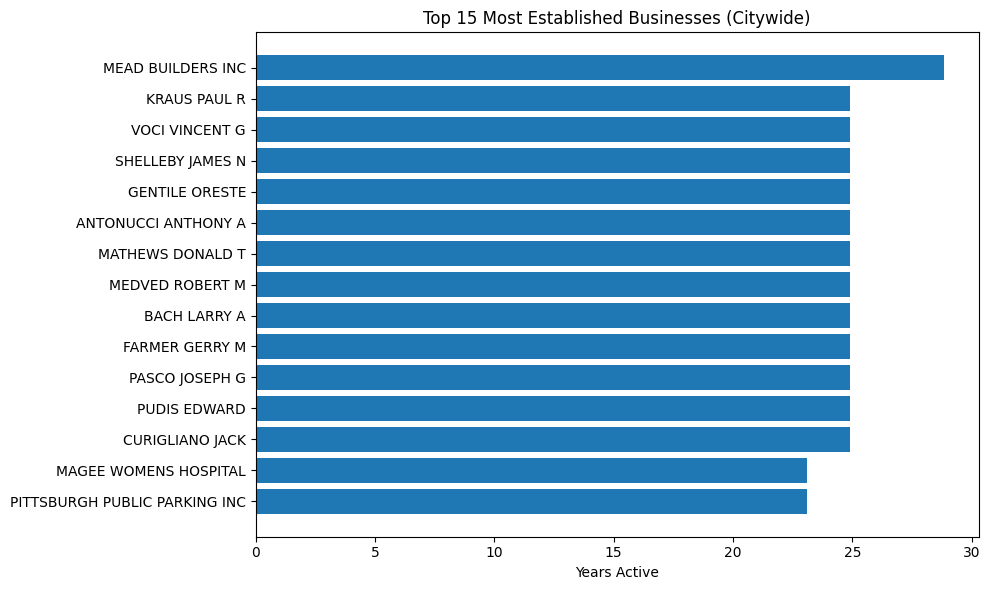

In [8]:
import matplotlib.pyplot as plt

top15 = combined_unique.nlargest(15, "years_active")
plt.figure(figsize=(10,6))
plt.barh(top15["business_name"][::-1], top15["years_active"][::-1])
plt.xlabel("Years Active")
plt.title("Top 15 Most Established Businesses (Citywide)")
plt.tight_layout()
plt.show()


# 7. Extract ZIP Codes from Addresses from Business Addresses to sort them into neighborhoods

In [10]:
# Extract ZIP Code from the end of the address field (5 digits)
business["zip"] = business["address"].str.extract(r"(\d{5})")

# Convert ZIP to string & drop rows without ZIP
business = business.dropna(subset=["zip"])
business["zip"] = business["zip"].astype(str)

business[["business_name", "address", "zip"]].head()


,business_name,address,zip
2,BLUFF'S PARKING LLC,"1522 5TH AVE, Pittsburgh, PA 15219-",15219
4,CONCORD HOTELS,"5310 LIBERTY AVE, Pittsburgh, PA 15232-",15232
5,LAMAR ADVERTISING,"3223 PENN AVE, Pittsburgh, PA 15201-",15201
7,LAMAR ADVERTISING,"2209 SAW MILL RUN BLVD, Pittsburgh, PA 15210-",15210
8,LAMAR ADVERTISING,"2640 LIBRARY RD, Pittsburgh, PA 15234-",15234


# 8. ZIP -> Neighborhood

In [11]:
zip_to_neighborhood = {
    "15201": "Lawrenceville",
    "15203": "South Side",
    "15206": "East Liberty",
    "15210": "Carrick",
    "15212": "North Side",
    "15213": "Oakland",
    "15214": "Perry North",
    "15217": "Squirrel Hill",
    "15218": "Regent Square",  
    "15222": "Downtown",
    "15224": "Bloomfield",
    "15228": "MT Lebanon",
    "15232": "Shadyside",
}


# 9. Apply ZIP to Neighborhood Mapping and Join with the Dataset that we already made

In [12]:
business["neighborhood"] = business["zip"].map(zip_to_neighborhood)
business = business.dropna(subset=["neighborhood"])

combined_unique = combined_unique.merge(
    business[["business_name", "neighborhood"]],
    on="business_name",
    how="left"
)

combined_unique = combined_unique.dropna(subset=["neighborhood"])
combined_unique.head()

,business_name,years_active,neighborhood
13,MAGEE WOMENS HOSPITAL,23.115674,Oakland
14,MAGEE WOMENS HOSPITAL,23.115674,Oakland
15,PITTSBURGH PUBLIC PARKING INC,23.115674,Lawrenceville
25,LARRY'S ROADHOUSE,14.658453,Carrick
29,KATHLEEN HILPERT,14.639288,Carrick


# 10. Calculate the Stability Score by Neighborhood

In [13]:
stability_score = (
    combined_unique.groupby("neighborhood")["years_active"]
    .mean()
    .sort_values(ascending=False)
)

stability_score


neighborhood
Downtown         9.812395
Oakland          8.921930
Shadyside        8.686507
South Side       8.335050
Lawrenceville    8.195209
Bloomfield       7.731302
East Liberty     7.490699
North Side       7.249401
Squirrel Hill    6.710611
Carrick          6.697281
Perry North      4.017912
Regent Square    0.172485
Name: years_active, dtype: float64

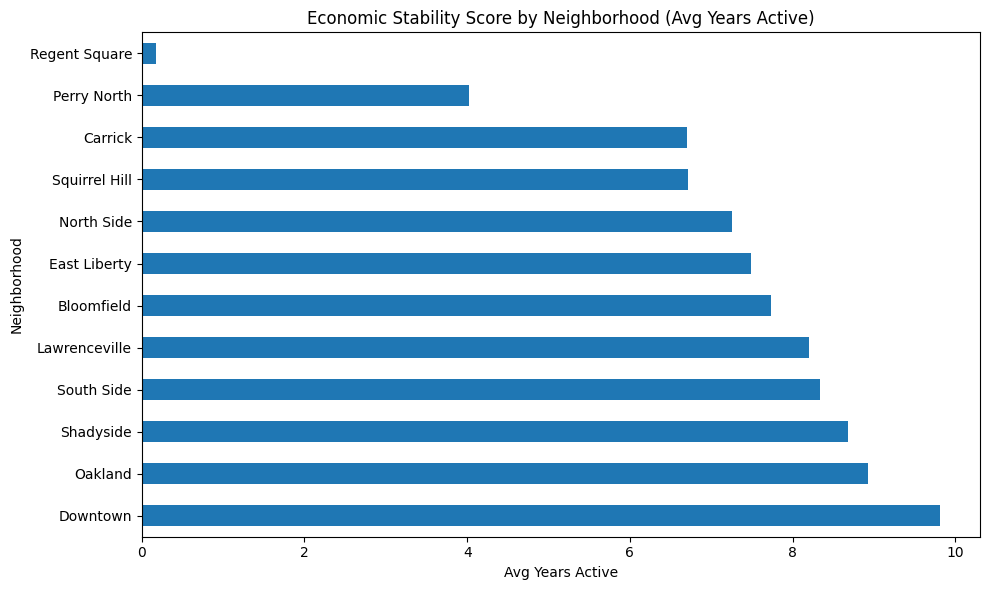

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
stability_score.plot(kind="barh")
plt.title("Economic Stability Score by Neighborhood (Avg Years Active)")
plt.xlabel("Avg Years Active")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.show()
